# Hito 1 - EDA y Preprocesamiento de Alta Fidelidad
Este notebook aplica un pipeline de realce médico equilibrado y realiza recortes enfocados directamente en las áreas de interés (Bounding Boxes) para un análisis visual óptimo.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import json

# Rutas base
data_dir = r'../FracAtlas_orvile/FracAtlas'
csv_path = os.path.join(data_dir, 'dataset.csv')
img_frac_dir = os.path.join(data_dir, 'images', 'Fractured')
img_non_frac_dir = os.path.join(data_dir, 'images', 'Non_fractured')
coco_json_path = os.path.join(data_dir, 'Annotations', 'COCO JSON', 'COCO_fracture_masks.json')

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'text.color': '#333333'
})

# Función robusta para leer imágenes
def leer_imagen(ruta, modo=cv2.IMREAD_COLOR):
    with open(ruta, 'rb') as f:
        img_array = np.frombuffer(f.read(), np.uint8)
    return cv2.imdecode(img_array, modo)

def get_path(row):
    folder = img_frac_dir if row['fractured'] == 1 else img_non_frac_dir
    return os.path.join(folder, row['image_id'])

## 1. Análisis Exploratorio (EDA)

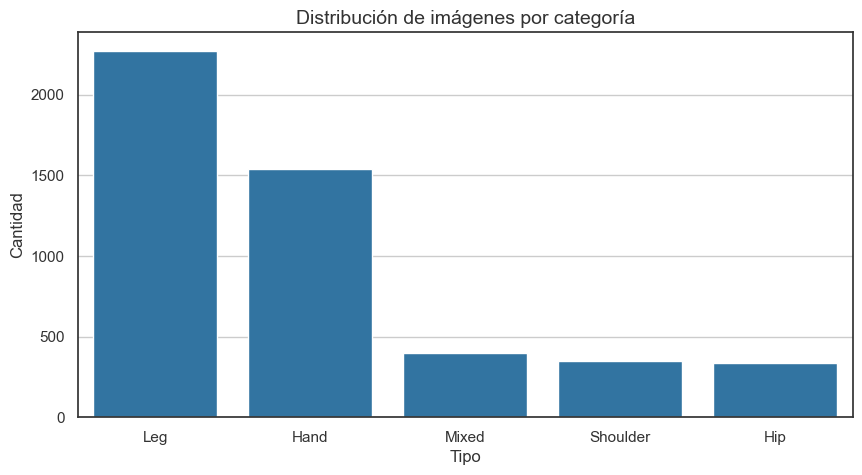

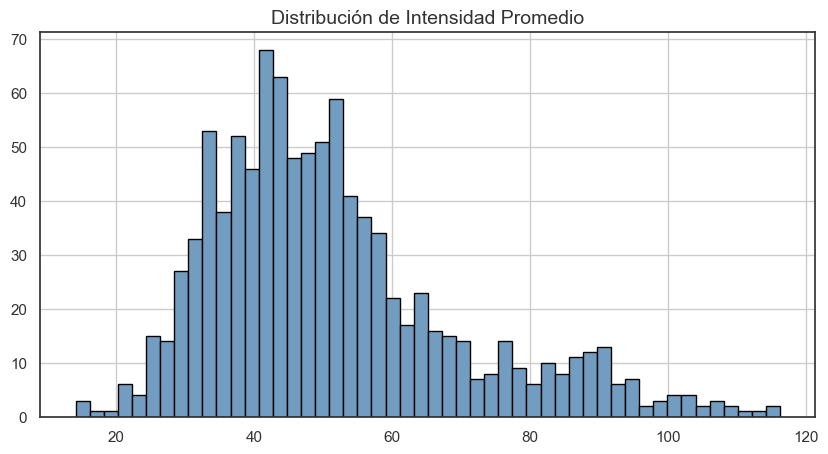

In [2]:
df = pd.read_csv(csv_path)
partes_cuerpo = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

# Distribución de Clases
conteos = []
for parte in partes_cuerpo:
    conteos.append({'Tipo': parte.capitalize(), 'Cantidad': df[df[parte] == 1].shape[0]})
df_count = pd.DataFrame(conteos).sort_values(by='Cantidad', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_count, x='Tipo', y='Cantidad', color='#1f77b4')
plt.title('Distribución de imágenes por categoría', fontsize=14)
plt.show()

# Intensidad Promedio
intensidades = []
for _, row in df.sample(min(len(df), 1000), random_state=42).iterrows():
    img = leer_imagen(get_path(row), cv2.IMREAD_GRAYSCALE)
    if img is not None: intensidades.append(np.mean(img))

plt.figure(figsize=(10, 5))
plt.hist(intensidades, bins=50, color='#729dc0', edgecolor='black')
plt.title('Distribución de Intensidad Promedio', fontsize=14)
plt.show()




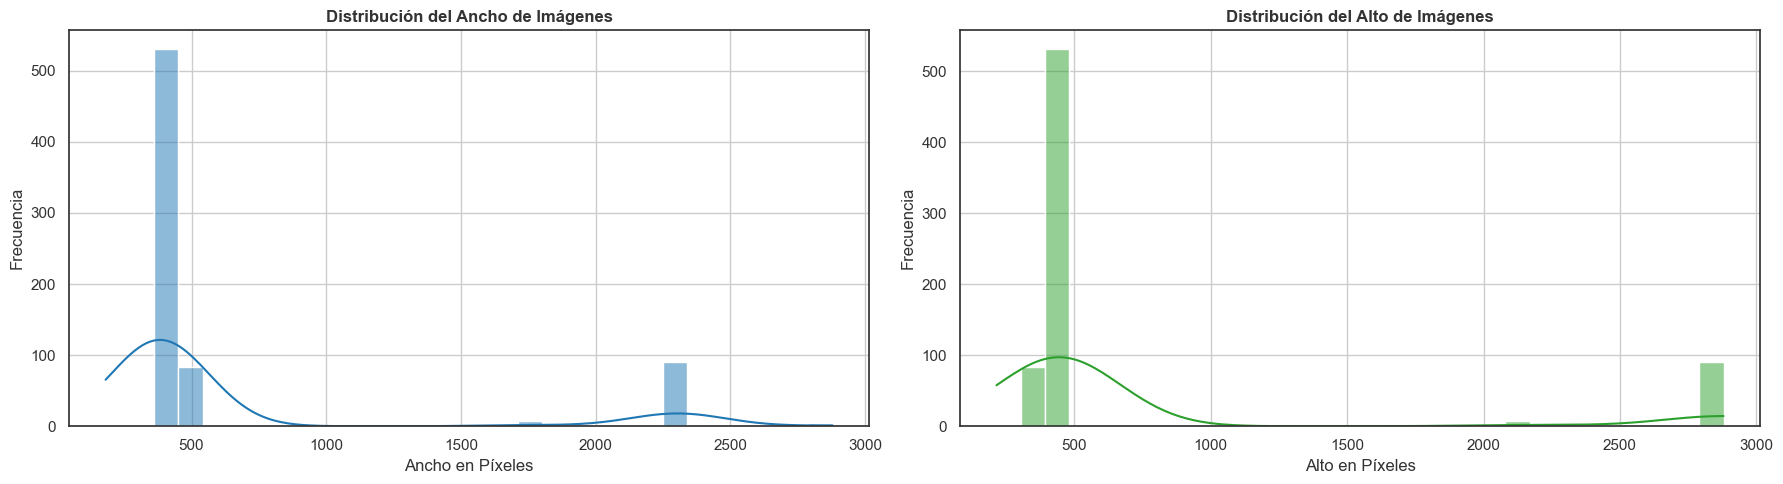

 ESTADÍSTICAS GEOMÉTRICAS DEL DATASET 
       Ancho (px)  Alto (px)  Relación de Aspecto (W/H)
count      717.00     717.00                     717.00
mean       653.80     777.81                       0.87
std        668.61     828.31                       0.14
min        181.00     214.00                       0.40
25%        373.00     454.00                       0.82
50%        373.00     454.00                       0.82
75%        454.00     454.00                       0.82
max       2880.00    2880.00                       1.74


In [3]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar las dimensiones desde el archivo COCO JSON
with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

# Extraer el ID, ancho, alto y calcular la relación de aspecto
dimensiones = []
for img in coco_data['images']:
    ancho = img['width']
    alto = img['height']
    relacion_aspecto = ancho / alto
    dimensiones.append({
        'image_id': img['file_name'],
        'Ancho (px)': ancho,
        'Alto (px)': alto,
        'Relación de Aspecto (W/H)': relacion_aspecto
    })

df_dimensiones = pd.DataFrame(dimensiones)

# 2. Configurar el lienzo (Matplotlib + Seaborn)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Gráfico 1: Distribución del Ancho
sns.histplot(data=df_dimensiones, x='Ancho (px)', kde=True, ax=axes[0], color='#1f77b4', bins=30)
axes[0].set_title('Distribución del Ancho de Imágenes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ancho en Píxeles')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Distribución del Alto
sns.histplot(data=df_dimensiones, x='Alto (px)', kde=True, ax=axes[1], color='#2ca02c', bins=30)
axes[1].set_title('Distribución del Alto de Imágenes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Alto en Píxeles')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 3. Métricas descriptivas para el informe
print("="*50)
print(" ESTADÍSTICAS GEOMÉTRICAS DEL DATASET ")
print("="*50)
print(df_dimensiones[['Ancho (px)', 'Alto (px)', 'Relación de Aspecto (W/H)']].describe().round(2))
print("="*50)

Generando grid de histogramas promedio...


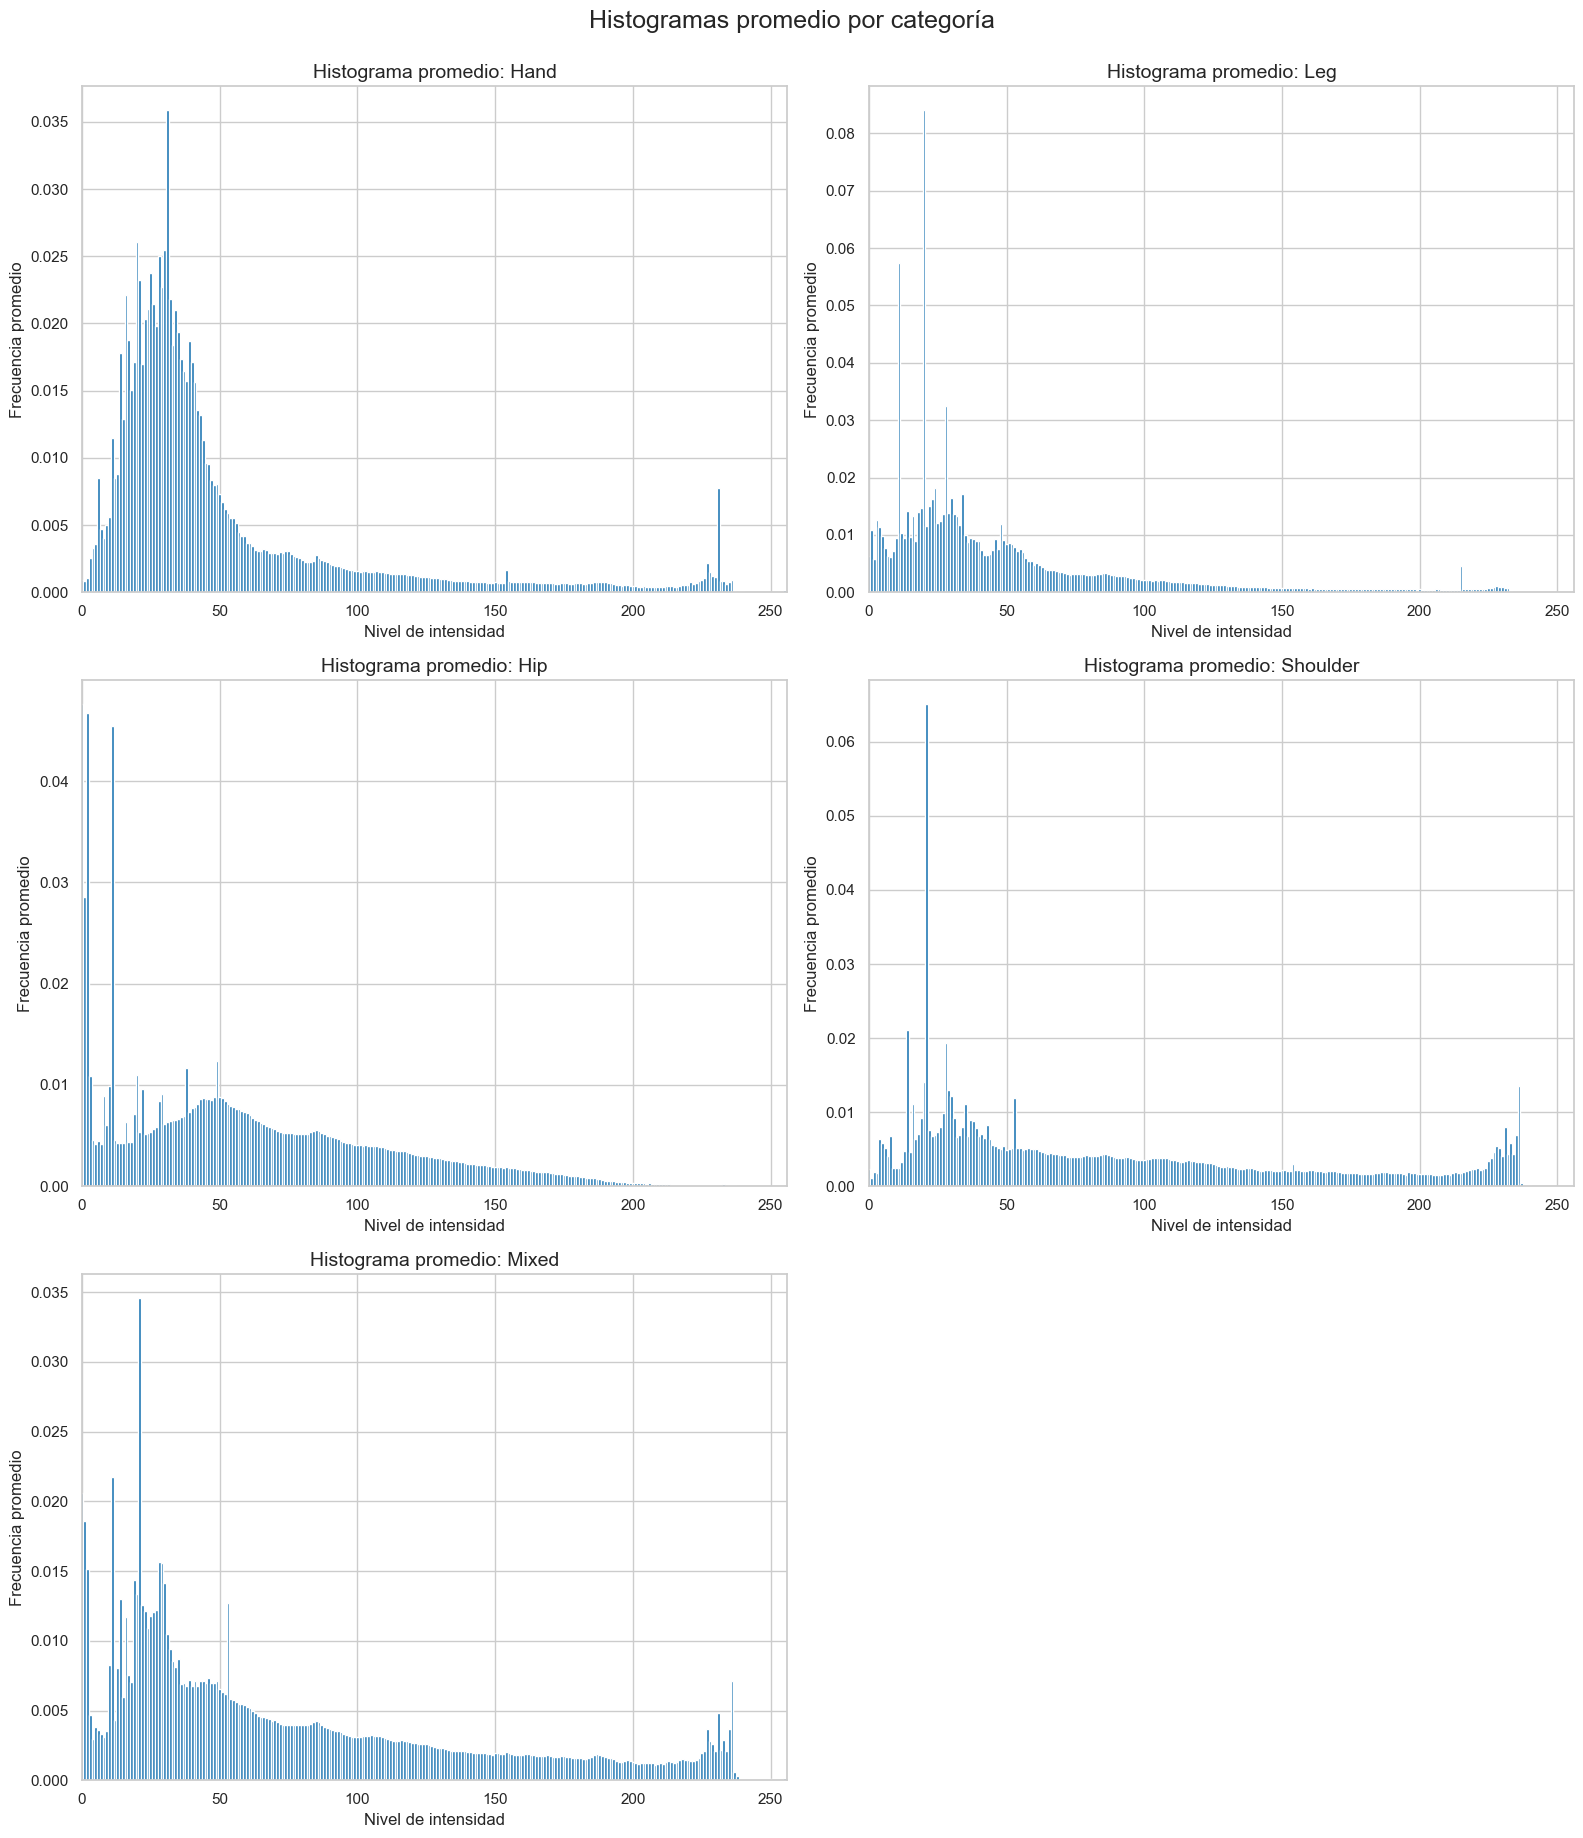

In [4]:
print("Generando grid de histogramas promedio...")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, parte in enumerate(partes_cuerpo):
    subset = df[df[parte] == 1].sample(min(df[df[parte] == 1].shape[0], 100), random_state=42)
    hists = []
    
    for _, row in subset.iterrows():
        img = leer_imagen(get_path(row), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            hist = cv2.calcHist([img], [0], None, [256], [0, 256])
            hist = hist / hist.sum()
            hists.append(hist)
    
    avg_hist = np.mean(hists, axis=0)
    
    axes[i].bar(range(256), avg_hist.flatten(), width=1.0, color='#1f77b4')
    axes[i].set_title(f'Histograma promedio: {parte.capitalize()}', fontsize=14)
    axes[i].set_xlabel('Nivel de intensidad')
    axes[i].set_ylabel('Frecuencia promedio')
    axes[i].set_xlim([0, 256])

if len(partes_cuerpo) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Histogramas promedio por categoría', fontsize=18, y=1.02)
plt.show()

## 2. Indexación de Anotaciones

In [5]:
with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

images_dict = {img['id']: img['file_name'] for img in coco_data['images']}
annotations_dict = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in annotations_dict: annotations_dict[img_id] = []
    annotations_dict[img_id].append(ann['bbox'])

## 3. Pipeline de Realce Equilibrado
Se ha ajustado el pipeline para evitar el sobreprocesamiento, manteniendo la nitidez sin sacrificar la naturalidad anatómica:
1. **Median Blur (3x3):** Reducción de ruido preservando bordes.
2. **CLAHE (clipLimit=3.0):** Rescate equilibrado de contraste.
3. **Balanced Unsharp Masking (k=1.2):** Realce de bordes natural.

In [6]:
def aplicar_pipeline_balanceado(img_gray):
    # 1. Filtro Mediana PRIMERO para eliminar ruido estático antes de amplificarlo
    img_median = cv2.medianBlur(img_gray, 3)

    # 2. CLAHE con clipLimit=4.0 sobre la imagen ya limpia
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_median)
    
    # 3. Unsharp Masking AGRESIVO (k=2.0)
    gaussian_blur = cv2.GaussianBlur(img_clahe, (0, 0), 1.5)
    img_enhanced = cv2.addWeighted(img_clahe, 3.0, gaussian_blur, -2.0, 0)
    
    return img_enhanced

## 4. Validación Enfocada por Categoría (BBox Crops)
Aplicamos el pipeline a muestras aleatorias, recortando la imagen exactamente alrededor de la fractura con un margen de 100px para contexto.

Visualización de fracturas: Recorte exacto a Bounding Box + Margen de Contexto


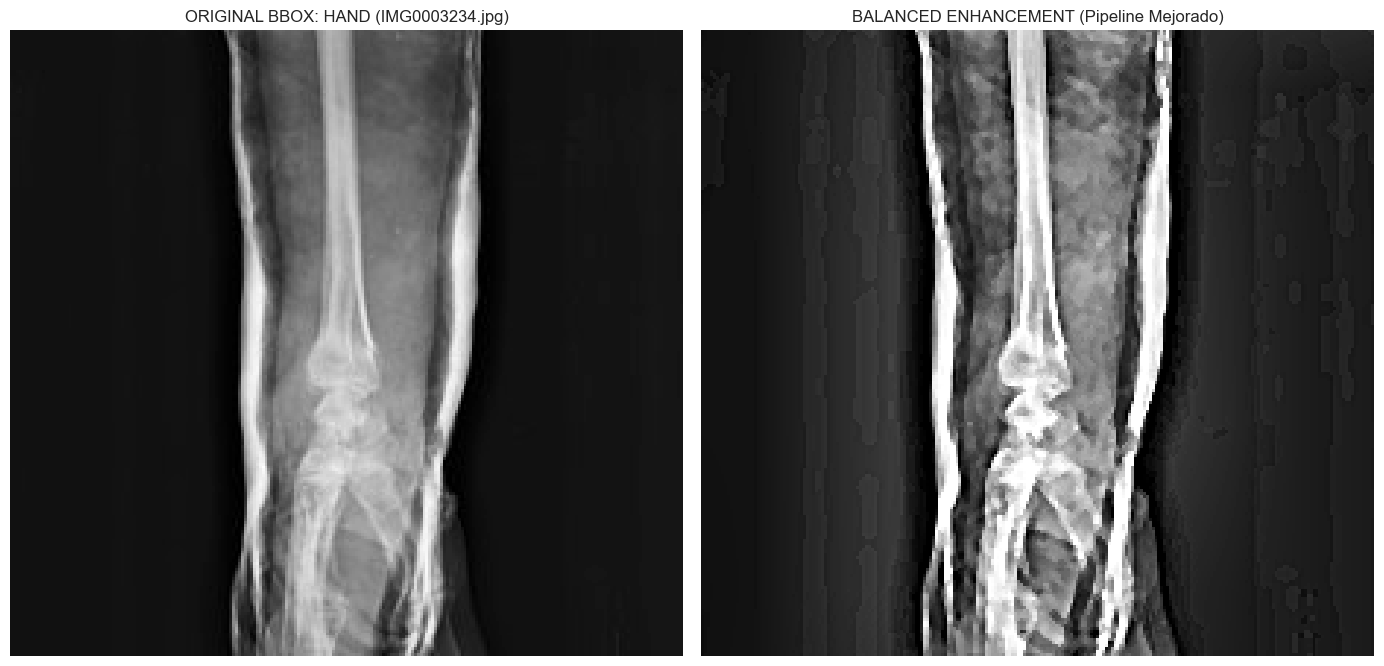

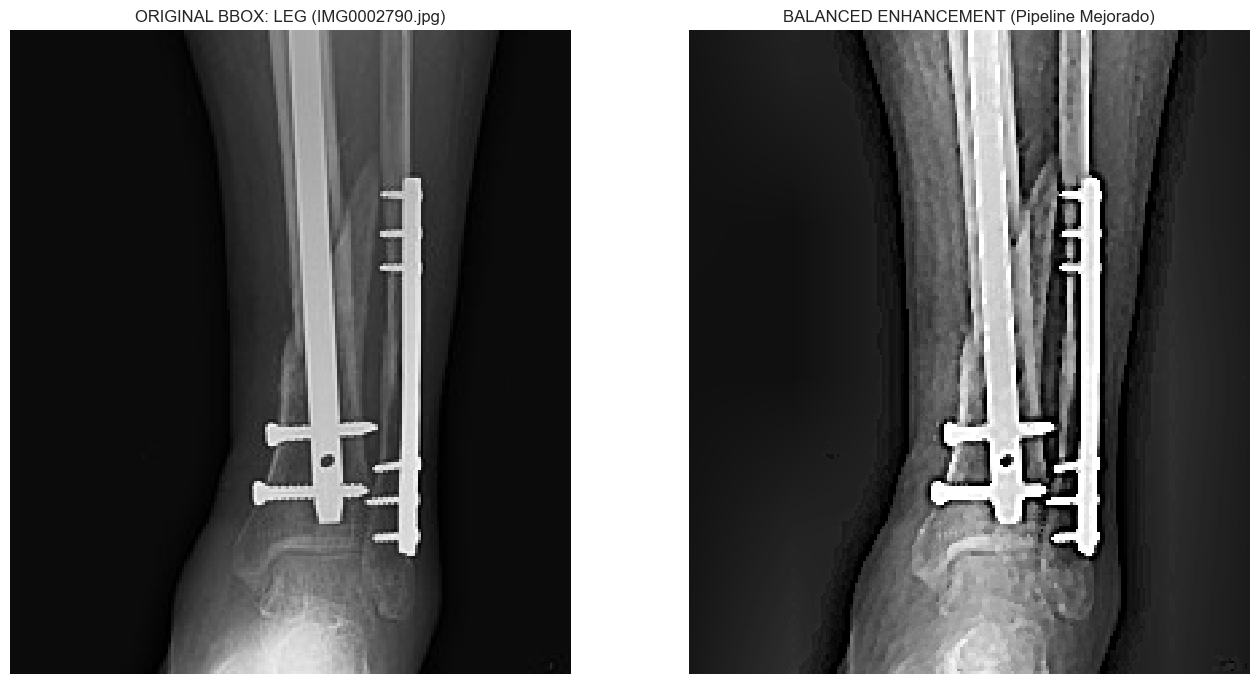

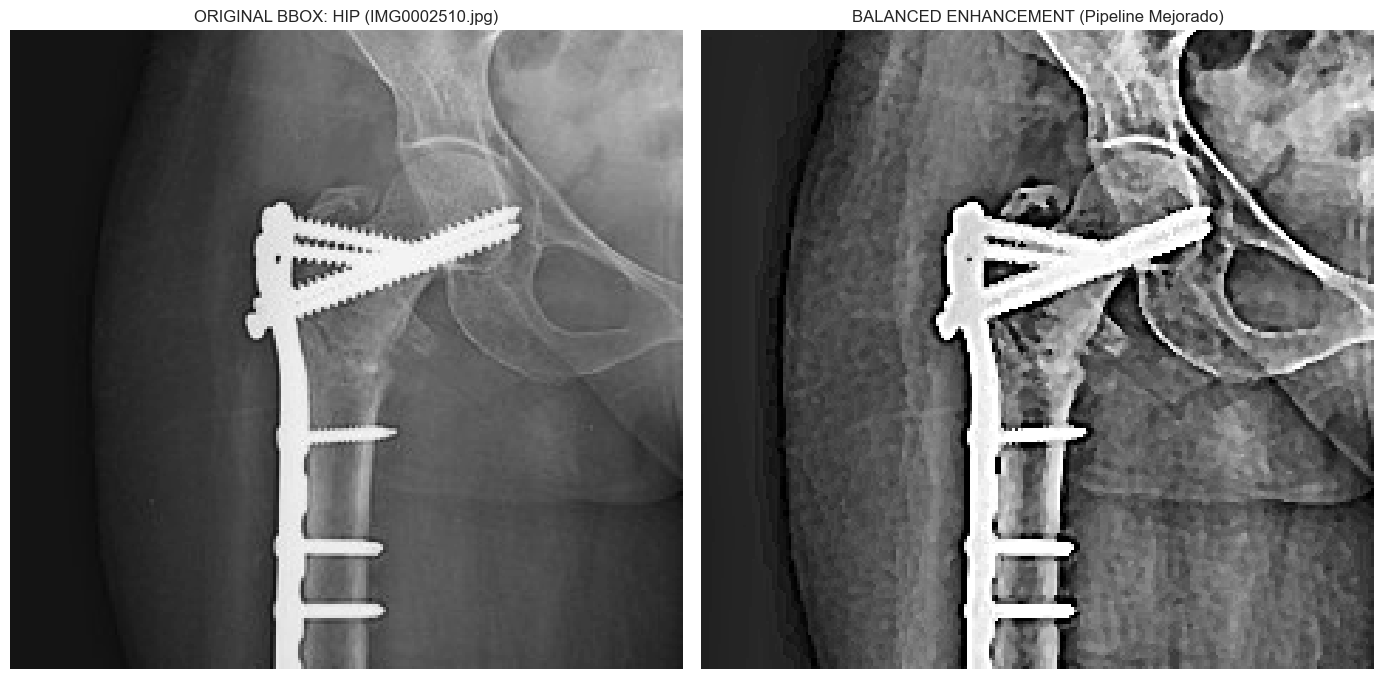

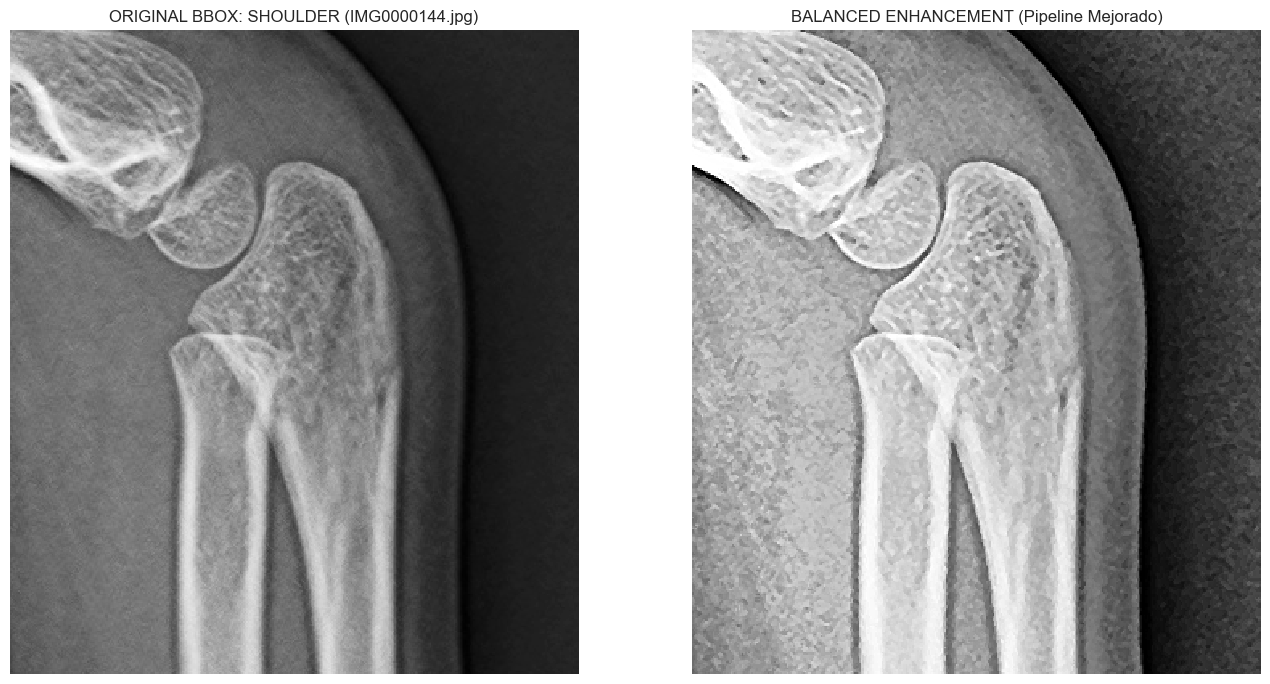

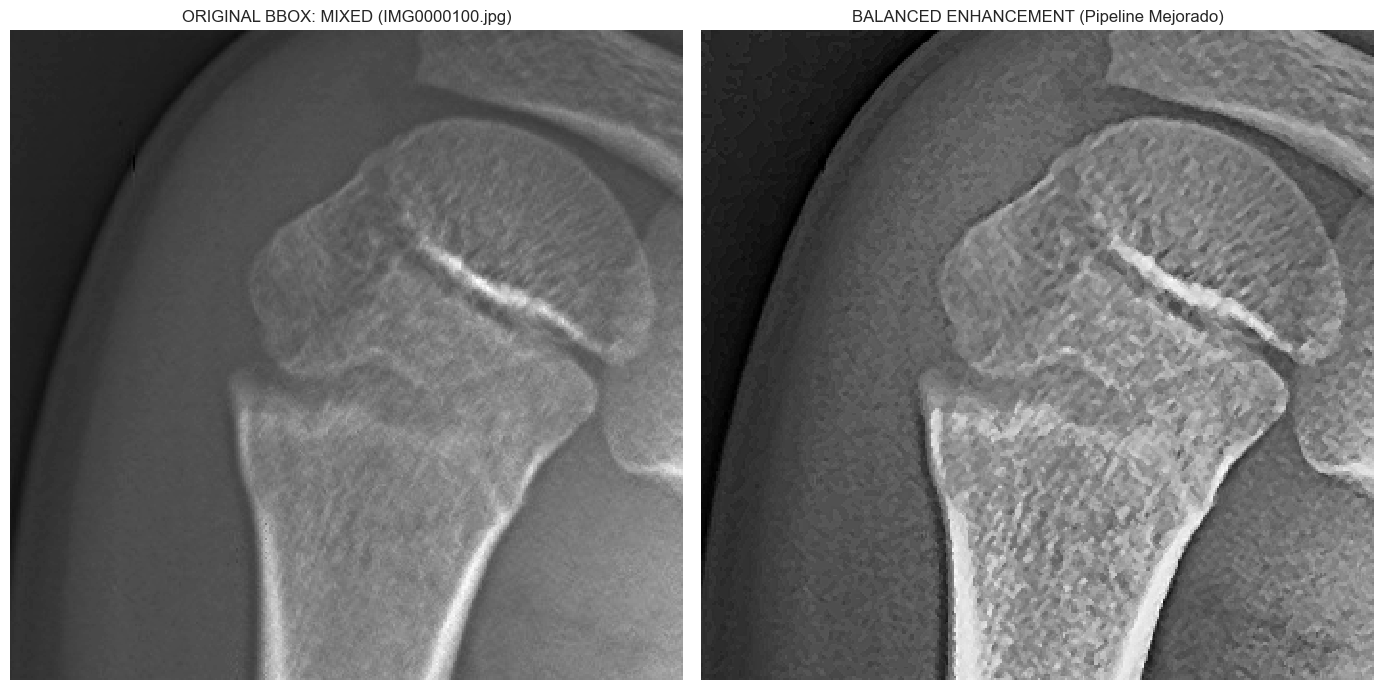

In [7]:
print("Visualización de fracturas: Recorte exacto a Bounding Box + Margen de Contexto")

for cat in partes_cuerpo:
    # Filtrar fracturadas de esta categoría
    fractured_cat = df[(df[cat] == 1) & (df['fractured'] == 1)]
    
    if not fractured_cat.empty:
        sample = fractured_cat.sample(1).iloc[0]
        fname = sample['image_id']
        ruta = os.path.join(img_frac_dir, fname)
        
        img_orig = leer_imagen(ruta, cv2.IMREAD_GRAYSCALE)
        if img_orig is None: continue
        
        img_proc = aplicar_pipeline_balanceado(img_orig)
        
        # Buscar bbox
        img_id_json = next((k for k, v in images_dict.items() if v == fname), None)
        bboxes = annotations_dict.get(img_id_json, [])
        
        if bboxes:
            # Tomamos la primera fractura de la imagen
            x, y, w, h = [int(v) for v in bboxes[0]]
            
            # Margen pequeño para contexto (100 píxeles)
            m = 100 
            
            y1, y2 = max(0, y-m), min(img_orig.shape[0], y+h+m)
            x1, x2 = max(0, x-m), min(img_orig.shape[1], x+w+m)
            
            # Recorte exacto
            crop_orig = img_orig[y1:y2, x1:x2]
            crop_proc = img_proc[y1:y2, x1:x2]
            
            # Visualización lado a lado
            fig, axes = plt.subplots(1, 2, figsize=(14, 7))

            axes[0].imshow(crop_orig, cmap='gray', interpolation='none')
            axes[0].set_title(f"ORIGINAL BBOX: {cat.upper()} ({fname})")
            axes[0].axis('off')
            
            axes[1].imshow(crop_proc, cmap='gray', interpolation='none')
            axes[1].set_title("BALANCED ENHANCEMENT (Pipeline Mejorado)")
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"No se encontró bbox para {fname} ({cat})")

Calculando histogramas promedio (muestreo de 50 imágenes por categoría)...


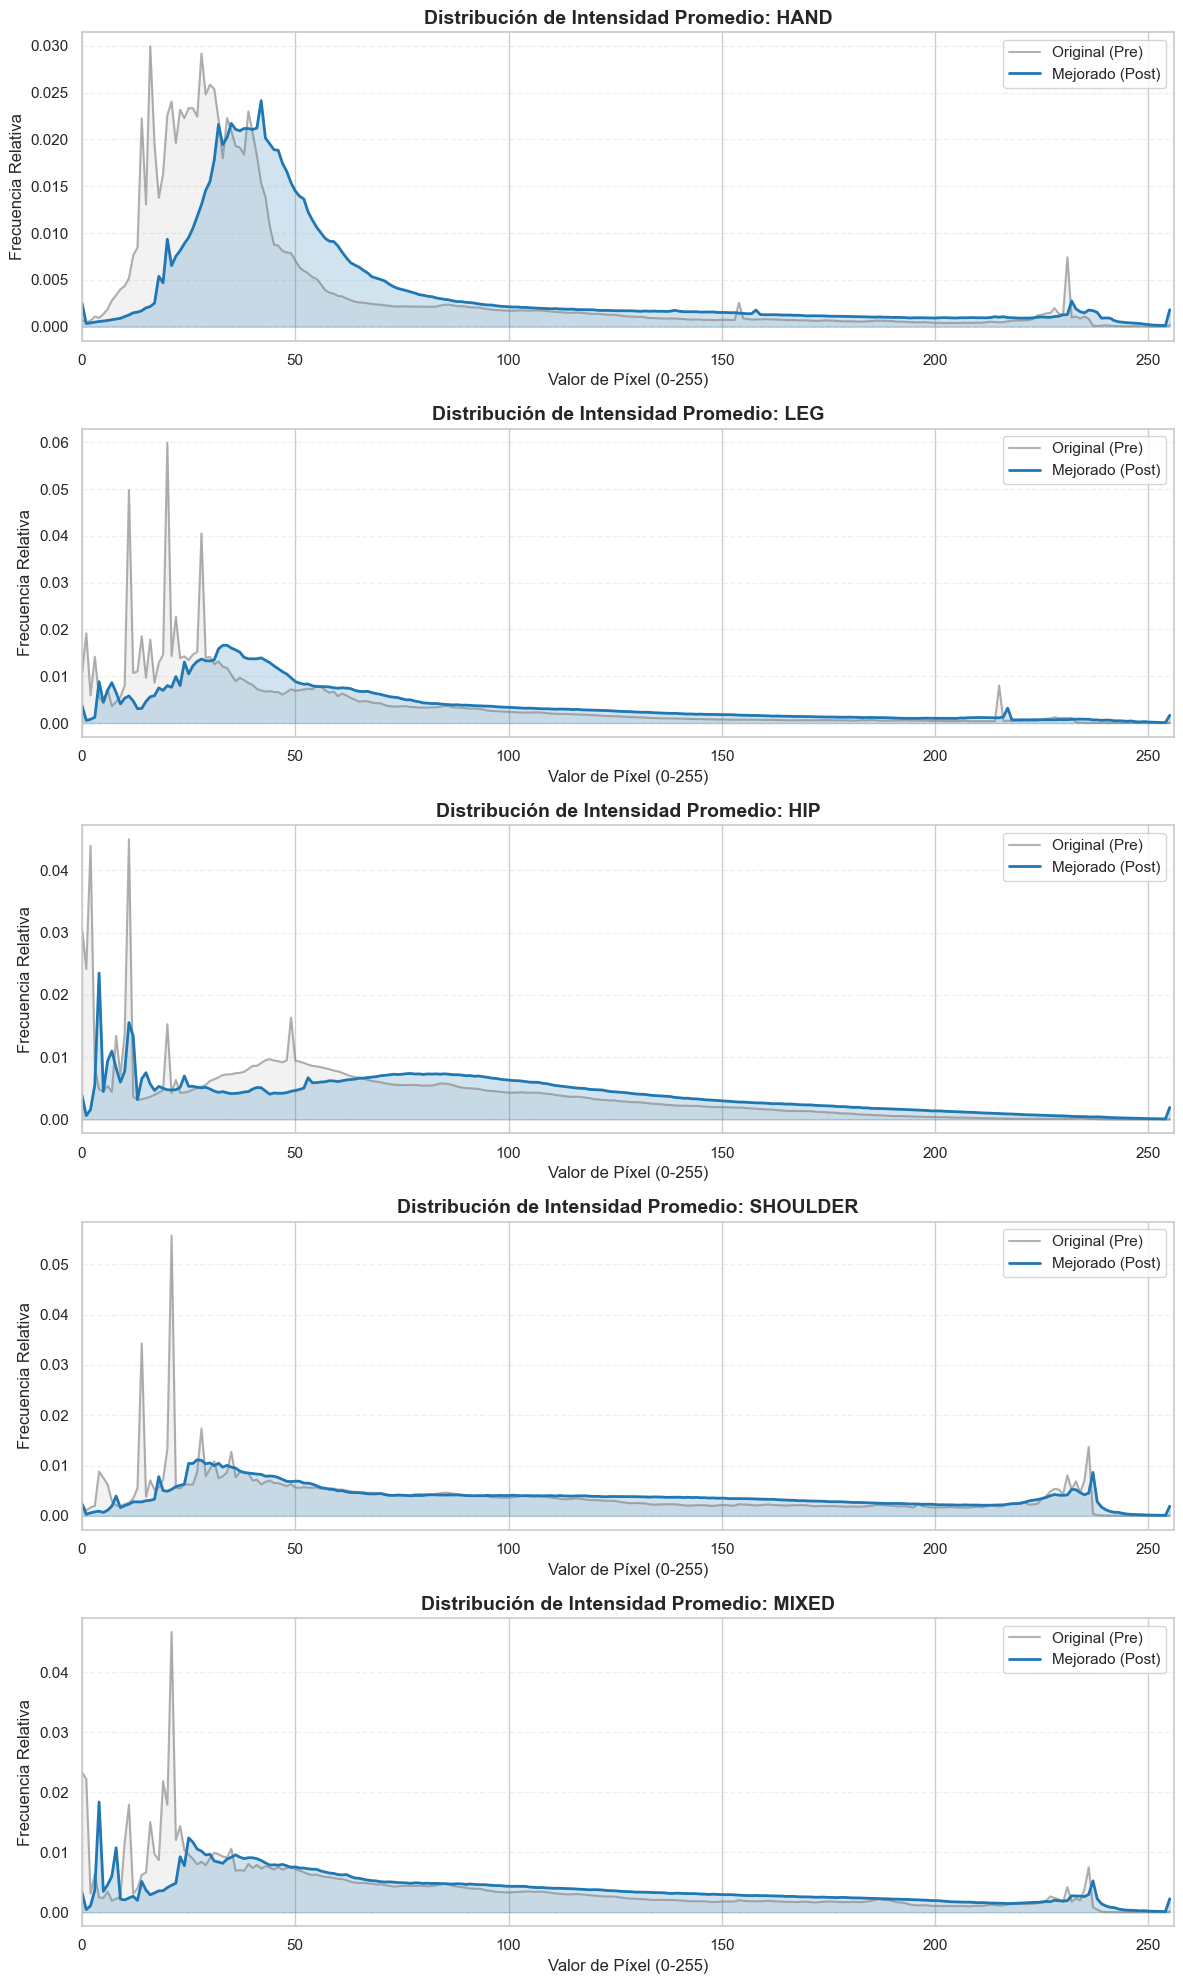

Análisis completado. Gráfico guardado como impacto_histogramas.png


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import json

base_dir = r'../FracAtlas_orvile/FracAtlas'
csv_path = os.path.join(base_dir, 'dataset.csv')
img_frac_dir = os.path.join(base_dir, 'images', 'Fractured')
img_non_frac_dir = os.path.join(data_dir, 'images', 'Non_fractured') if 'data_dir' in locals() else os.path.join(base_dir, 'images', 'Non_fractured')

# Partes del cuerpo a analizar
partes_cuerpo = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

def leer_imagen(ruta, modo=cv2.IMREAD_GRAYSCALE):
    try:
        with open(ruta, 'rb') as f:
            img_array = np.frombuffer(f.read(), np.uint8)
        return cv2.imdecode(img_array, modo)
    except:
        return None

def aplicar_pipeline_balanceado(img_gray):
    # 1. CLAHE (clipLimit=3.0)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)
    
    # 2. Filtro Mediana (3x3)
    img_median = cv2.medianBlur(img_clahe, 3)
    
    # 3. Unsharp Masking Moderado (k=1.2)
    gaussian_blur = cv2.GaussianBlur(img_median, (0,0), 1.0)
    img_enhanced = cv2.addWeighted(img_median, 2.2, gaussian_blur, -1.2, 0)
    
    return img_enhanced

def analizar_impacto_histogramas(df, n_muestras=50):
    print(f"Calculando histogramas promedio (muestreo de {n_muestras} imágenes por categoría)...")
    
    hist_pre_avg = {}
    hist_post_avg = {}

    for cat in partes_cuerpo:
        # Filtrar imágenes que pertenezcan a la categoría
        subset = df[df[cat] == 1]
        if subset.empty: continue
        
        # Tomar muestra aleatoria para no saturar memoria
        samples = subset.sample(min(len(subset), n_muestras), random_state=42)
        
        hists_pre = []
        hists_post = []

        for _, row in samples.iterrows():
            # Determinar carpeta según si es fractura o no
            folder = img_frac_dir if row['fractured'] == 1 else img_non_frac_dir
            ruta = os.path.join(folder, row['image_id'])
            
            img_orig = leer_imagen(ruta)
            if img_orig is not None:
                # Histograma Original
                h_pre = cv2.calcHist([img_orig], [0], None, [256], [0, 256])
                hists_pre.append(h_pre / h_pre.sum()) # Normalizar frecuencia
                
                # Procesar y Histograma Post
                img_proc = aplicar_pipeline_balanceado(img_orig)
                h_post = cv2.calcHist([img_proc], [0], None, [256], [0, 256])
                hists_post.append(h_post / h_post.sum()) # Normalizar frecuencia

        if hists_pre:
            hist_pre_avg[cat] = np.mean(hists_pre, axis=0)
            hist_post_avg[cat] = np.mean(hists_post, axis=0)

    return hist_pre_avg, hist_post_avg


if __name__ == "__main__":
    if os.path.exists(csv_path):
        df_main = pd.read_csv(csv_path)
        h_pre, h_post = analizar_impacto_histogramas(df_main)

        # Crear figura con subplots para cada categoría
        fig, axes = plt.subplots(len(h_pre), 1, figsize=(12, 4 * len(h_pre)))
        if len(h_pre) == 1: axes = [axes]

        for i, cat in enumerate(h_pre.keys()):
            ax = axes[i]
            # Graficar curvas promedio
            ax.plot(h_pre[cat], color='gray', label='Original (Pre)', alpha=0.6, linewidth=1.5)
            ax.plot(h_post[cat], color='#1f77b4', label='Mejorado (Post)', linewidth=2)
            
            # Rellenar áreas
            ax.fill_between(range(256), h_pre[cat].flatten(), color='gray', alpha=0.1)
            ax.fill_between(range(256), h_post[cat].flatten(), color='#1f77b4', alpha=0.2)
            
            ax.set_title(f'Distribución de Intensidad Promedio: {cat.upper()}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Valor de Píxel (0-255)')
            ax.set_ylabel('Frecuencia Relativa')
            ax.legend()
            ax.set_xlim([0, 256])
            ax.grid(axis='y', linestyle='--', alpha=0.3)

        plt.tight_layout()
        output_img = "impacto_histogramas.png"
        plt.savefig(output_img)
        plt.show()
        print(f"Análisis completado. Gráfico guardado como {output_img}")
    else:
        print("Error: No se encontró el archivo dataset.csv en la ruta especificada.")
